<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/API/NeqSimPVTAPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeqSim PVT API: executable property workflows

This notebook provides a reproducible local NeqSim workflow for common PVT
calculations. Every calculation is executable in a clean Google Colab runtime.

The examples cover pure methane, a defined three-phase fluid, a characterized
gas condensate, a hybrid SRK/GERG gas-property workflow, direct GERG-2008 gas
properties, and a CPA temperature sweep.


## Learning outcomes

After completing the notebook, you can:

1. build unit-explicit PVT requests;
2. run TP flashes and retrieve phase properties;
3. characterize heavy fractions by molar mass and relative density;
4. apply GERG-2008 only within its gas-phase validity range;
5. compare SRK and CPA phase behavior; and
6. validate composition closure, phase closure, and property trends.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim==3.16.0",
        ],
        check=True,
    )

from importlib.metadata import version

print("NeqSim version:", version("neqsim"))
print("Python version:", sys.version.split()[0])


NeqSim version: 3.16.0
Python version: 3.12.13


## Basis, units, and models

All compositions are mole fractions. Pressure is absolute and reported in bar;
temperature is in kelvin. The cubic models use volume correction. SRK is used
for general-purpose flashes, GERG-2008 for single-phase gas
properties, and CPA for the associating water-containing case.

Every feed must close:

$$
\sum_i z_i = 1
$$


In [2]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim.thermo import TPflash
from neqsim.thermo import addComponent
from neqsim.thermo import addOilFractions
from neqsim.thermo import fluid

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")


For a homogeneous phase, the compressibility factor is

$$
Z = \frac{P V_m}{R T}
$$

The reported density, heat capacities, viscosity, and thermal conductivity are
calculated by NeqSim after the equilibrium state has been initialized.


In [3]:
def validate_composition(components, fractions, label):
    if len(components) != len(fractions):
        raise ValueError(f"{label}: components and fractions differ in length")
    if any(value < 0.0 for value in fractions):
        raise ValueError(f"{label}: negative mole fraction")
    total = float(sum(fractions))
    if not math.isclose(total, 1.0, abs_tol=1.0e-12):
        raise ValueError(f"{label}: mole fractions sum to {total:.12f}")
    return total


def phase_names(system):
    return [
        str(system.getPhase(index).getPhaseTypeName())
        for index in range(system.getNumberOfPhases())
    ]


In [4]:
def build_fluid(
    model,
    temperature_k,
    pressure_bara,
    components,
    fractions,
    pseudo=None,
    mixing_rule="classic",
    multiphase=True,
):
    validate_composition(
        components + ([] if pseudo is None else pseudo["names"]),
        fractions + ([] if pseudo is None else pseudo["fractions"]),
        model,
    )
    system = fluid(model, temperature_k, pressure_bara)
    for name, fraction in zip(components, fractions):
        addComponent(system, name, fraction)
    if pseudo is not None:
        addOilFractions(
            system,
            pseudo["names"],
            pseudo["fractions"],
            pseudo["molar_mass_kg_per_mol"],
            pseudo["relative_density"],
            lumpComponents=False,
        )
    system.setMixingRule(mixing_rule)
    system.setMultiPhaseCheck(multiphase)
    return system


### Reusable result schema

The next helpers return named, unit-bearing columns. Missing phases are omitted
instead of being represented by ambiguous `NaN` blocks.


In [5]:
def phase_record(system, phase_index, case):
    phase = system.getPhase(phase_index)
    cp = float(phase.getCp("J/molK"))
    cv = float(phase.getCv("J/molK"))
    return {
        "case": case,
        "phase": str(phase.getPhaseTypeName()),
        "temperature_K": float(system.getTemperature("K")),
        "pressure_bara": float(system.getPressure("bara")),
        "phase_mole_fraction": float(phase.getMoleFraction()),
        "density_kg_per_m3": float(phase.getDensity("kg/m3")),
        "Z": float(phase.getZ()),
        "molar_mass_g_per_mol": float(phase.getMolarMass()) * 1000.0,
        "enthalpy_J_per_mol": float(phase.getEnthalpy("J/mol")),
        "entropy_J_per_molK": float(phase.getEntropy("J/molK")),
        "Cp_J_per_molK": cp,
        "Cv_J_per_molK": cv,
        "gamma": cp / cv,
        "viscosity_Pa_s": float(phase.getViscosity("kg/msec")),
        "conductivity_W_per_mK": float(
            phase.getThermalConductivity("W/mK")
        ),
    }


In [6]:
def run_tp_case(system, case):
    TPflash(system)
    system.initPhysicalProperties()
    records = [
        phase_record(system, index, case)
        for index in range(system.getNumberOfPhases())
    ]
    return system, pd.DataFrame(records)


def phase_fraction_map(system):
    return {
        str(system.getPhase(index).getPhaseTypeName()): float(
            system.getPhase(index).getMoleFraction()
        )
        for index in range(system.getNumberOfPhases())
    }


## Example 1 — pure methane properties

Three pressure/temperature pairs demonstrate the workflow. SRK is suitable for
illustrating the API; a reference equation may be selected when metrology-grade
gas properties are required.


In [7]:
methane_points = [
    ("point 1", 298.0, 30.1),
    ("point 2", 291.2, 31.2),
    ("point 3", 313.3, 50.0),
]
methane_frames = []
methane_systems = []

for label, temperature_k, pressure_bara in methane_points:
    methane = build_fluid(
        "srk",
        temperature_k,
        pressure_bara,
        ["methane"],
        [1.0],
        multiphase=False,
    )
    methane, frame = run_tp_case(methane, label)
    methane_systems.append(methane)
    methane_frames.append(frame)

methane_results = pd.concat(methane_frames, ignore_index=True)
print(
    methane_results[
        [
            "case",
            "temperature_K",
            "pressure_bara",
            "density_kg_per_m3",
            "Z",
            "Cp_J_per_molK",
            "viscosity_Pa_s",
        ]
    ].to_string(index=False)
)


   case  temperature_K  pressure_bara  density_kg_per_m3        Z  Cp_J_per_molK  viscosity_Pa_s
point 1          298.0           30.1          20.514479 0.950867      39.077191        0.000012
point 2          291.2           31.2          21.918891 0.944063      39.180142        0.000012
point 3          313.3           50.0          32.895105 0.937426      41.420281        0.000013


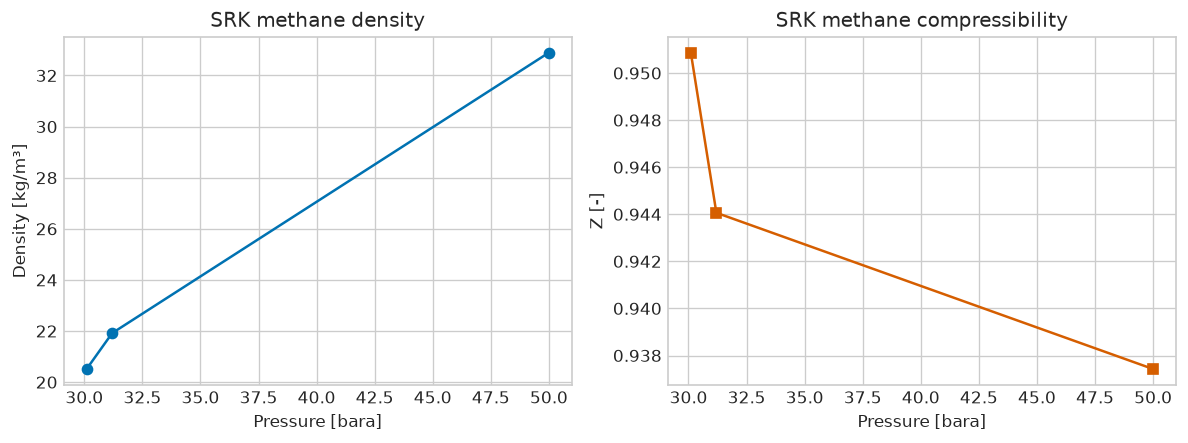

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(
    methane_results["pressure_bara"],
    methane_results["density_kg_per_m3"],
    "o-",
    color="#0072B2",
)
axes[0].set(
    title="SRK methane density",
    xlabel="Pressure [bara]",
    ylabel="Density [kg/m³]",
)
axes[1].plot(
    methane_results["pressure_bara"],
    methane_results["Z"],
    "s-",
    color="#D55E00",
)
axes[1].set(
    title="SRK methane compressibility",
    xlabel="Pressure [bara]",
    ylabel="Z [-]",
)
fig.tight_layout()
plt.show()


The methane remains single-phase gas at all three points. Density increases
with pressure, while the compressibility factor remains close to—but below—the
ideal-gas value of one.


## Example 2 — defined water/hydrocarbon fluid

This example uses water, methane, ethane, propane, and n-heptane. Multiphase
checking is enabled because gas, oil, and aqueous phases can coexist.


In [9]:
defined_components = [
    "water",
    "methane",
    "ethane",
    "propane",
    "n-heptane",
]
defined_fractions = [0.10, 0.60, 0.10, 0.10, 0.10]
defined_frames = []
defined_systems = []

for label, temperature_k, pressure_bara in methane_points:
    defined = build_fluid(
        "srk",
        temperature_k,
        pressure_bara,
        defined_components,
        defined_fractions,
    )
    defined, frame = run_tp_case(defined, label)
    defined_systems.append(defined)
    defined_frames.append(frame)

defined_results = pd.concat(defined_frames, ignore_index=True)
print(
    defined_results[
        [
            "case",
            "phase",
            "phase_mole_fraction",
            "density_kg_per_m3",
            "Z",
            "viscosity_Pa_s",
        ]
    ].to_string(index=False)
)


   case   phase  phase_mole_fraction  density_kg_per_m3        Z  viscosity_Pa_s
point 1     gas             0.732530          27.361292 0.908452        0.000012
point 1     oil             0.168187         621.855347 0.158675        0.000248
point 1 aqueous             0.099283        1002.440839 0.028921        0.000897
point 2     gas             0.719036          28.872803 0.899981        0.000011
point 2     oil             0.181414         620.416332 0.162316        0.000247
point 2 aqueous             0.099550        1008.672877 0.030535        0.001057
point 3     gas             0.714301          45.291879 0.875068        0.000013
point 3     oil             0.186880         583.866988 0.243221        0.000184
point 3 aqueous             0.098819         988.445072 0.046184        0.000651


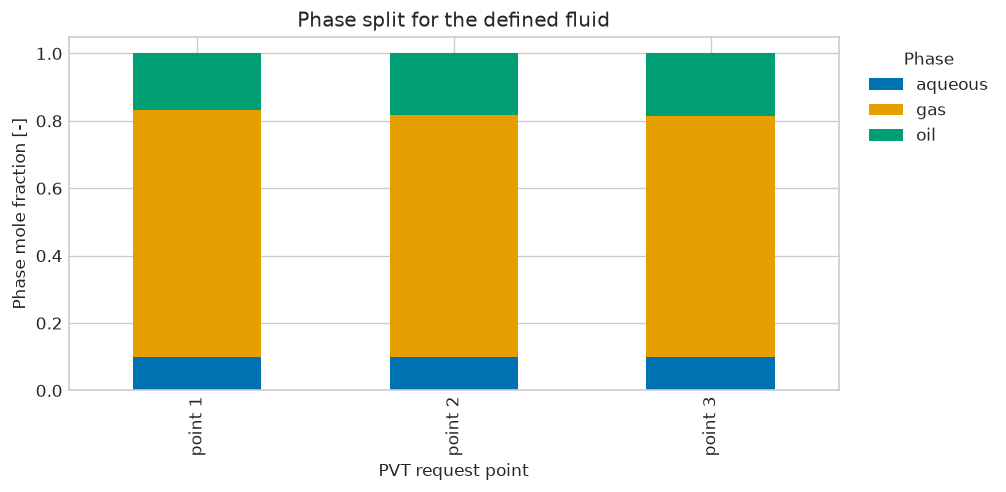

In [10]:
defined_plot = defined_results.pivot(
    index="case",
    columns="phase",
    values="phase_mole_fraction",
).fillna(0.0)
colors = ["#0072B2", "#E69F00", "#009E73"]
ax = defined_plot.plot(
    kind="bar",
    stacked=True,
    color=colors[: len(defined_plot.columns)],
    figsize=(8.5, 4.2),
)
ax.set(
    title="Phase split for the defined fluid",
    xlabel="PVT request point",
    ylabel="Phase mole fraction [-]",
)
ax.legend(title="Phase", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


Phase closure is checked using

$$
\sum_{\alpha} \beta_{\alpha} = 1
$$

The three phases have physically distinct densities, which makes positional
arrays especially error-prone and supports the named-table interface used here.


## Example 3 — characterized gas condensate with SRK

Three pseudo-components use molar masses of 90, 101, and 140 g/mol and relative
densities of 0.75, 0.81, and 0.90. The 50 bara temperature sweep shows how the
equilibrium phase split changes.


In [11]:
condensate_components = [
    "water",
    "methane",
    "ethane",
    "propane",
    "n-heptane",
]
condensate_fractions = [0.25, 0.15, 0.10, 0.10, 0.10]
heavy_fraction = {
    "names": ["CHCmp_1", "CHCmp_2", "CHCmp_3"],
    "fractions": [0.10, 0.10, 0.10],
    "molar_mass_kg_per_mol": [0.090, 0.101, 0.140],
    "relative_density": [0.75, 0.81, 0.90],
}
validate_composition(
    condensate_components + heavy_fraction["names"],
    condensate_fractions + heavy_fraction["fractions"],
    "characterized condensate",
)
print(pd.DataFrame(heavy_fraction).to_string(index=False))


  names  fractions  molar_mass_kg_per_mol  relative_density
CHCmp_1        0.1                  0.090              0.75
CHCmp_2        0.1                  0.101              0.81
CHCmp_3        0.1                  0.140              0.90


In [12]:
srk_sweep_rows = []
srk_sweep_systems = []

for temperature_k in np.linspace(300.0, 390.0, 10):
    condensate = build_fluid(
        "srk",
        float(temperature_k),
        50.0,
        condensate_components,
        condensate_fractions,
        pseudo=heavy_fraction,
    )
    condensate, _ = run_tp_case(
        condensate,
        f"{temperature_k:.0f} K",
    )
    fractions = phase_fraction_map(condensate)
    srk_sweep_systems.append(condensate)
    srk_sweep_rows.append(
        {
            "temperature_K": temperature_k,
            "gas": fractions.get("gas", 0.0),
            "oil": fractions.get("oil", 0.0),
            "aqueous": fractions.get("aqueous", 0.0),
        }
    )

srk_sweep = pd.DataFrame(srk_sweep_rows)
print(srk_sweep.to_string(index=False))


 temperature_K      gas      oil  aqueous
         300.0 0.051176 0.700050 0.248773
         310.0 0.066059 0.685785 0.248156
         320.0 0.080299 0.672410 0.247290
         330.0 0.094154 0.659747 0.246098
         340.0 0.107846 0.647674 0.244479
         350.0 0.121593 0.636100 0.242306
         360.0 0.135645 0.624936 0.239419
         370.0 0.150317 0.614071 0.235612
         380.0 0.166027 0.603350 0.230623
         390.0 0.183348 0.592544 0.224108


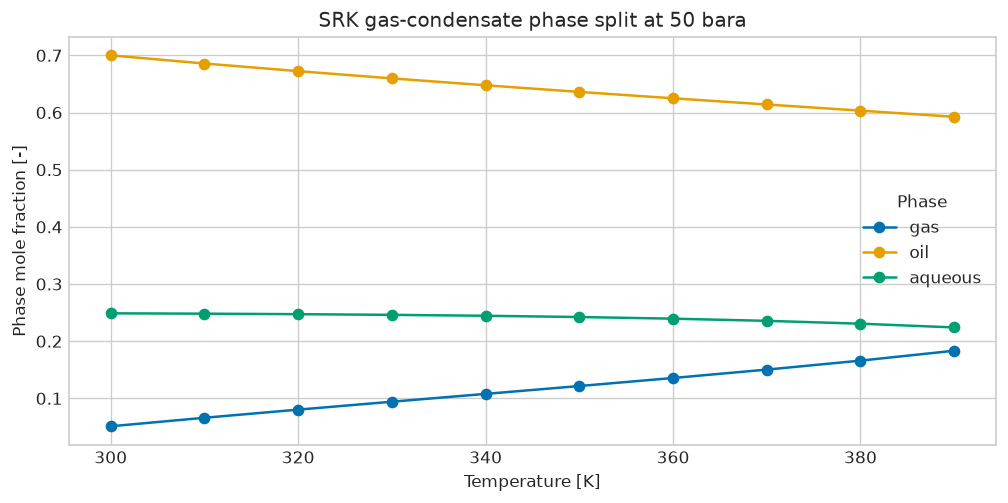

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.3))
for phase, color in zip(
    ["gas", "oil", "aqueous"],
    ["#0072B2", "#E69F00", "#009E73"],
):
    ax.plot(
        srk_sweep["temperature_K"],
        srk_sweep[phase],
        "o-",
        label=phase,
        color=color,
    )
ax.set(
    title="SRK gas-condensate phase split at 50 bara",
    xlabel="Temperature [K]",
    ylabel="Phase mole fraction [-]",
)
ax.legend(title="Phase")
fig.tight_layout()
plt.show()


The aqueous fraction is comparatively insensitive to temperature, whereas the
gas/oil allocation changes as heavy hydrocarbons vaporize. The characterization
data are model inputs, not measured assay replacements.


## Example 4 — SRK equilibrium with GERG gas properties

The hybrid calculation is explicit: SRK performs the multiphase split, then the
named gas-phase components are normalized and passed to a single-phase
GERG-2008 property model. Pseudo-components are excluded from GERG, and the
fraction of the gas phase covered by named components is reported.


In [14]:
gerg_supported = {
    "water",
    "methane",
    "ethane",
    "propane",
    "n-heptane",
}
hybrid_rows = []

for label, temperature_k, pressure_bara in methane_points:
    equilibrium = build_fluid(
        "srk",
        temperature_k,
        pressure_bara,
        condensate_components,
        condensate_fractions,
        pseudo=heavy_fraction,
    )
    equilibrium, _ = run_tp_case(equilibrium, label)
    gas = equilibrium.getPhase("gas")
    named = {}
    for index in range(gas.getNumberOfComponents()):
        component = gas.getComponent(index)
        name = str(component.getComponentName())
        if name in gerg_supported:
            named[name] = float(component.getx())
    coverage = sum(named.values())
    normalized = {name: value / coverage for name, value in named.items()}

    gerg = fluid("gerg-2008", temperature_k, pressure_bara)
    for name, fraction in normalized.items():
        addComponent(gerg, name, fraction)
    gerg.setNumberOfPhases(1)
    gerg.init(3)
    gerg.initPhysicalProperties()
    gerg_gas = gerg.getPhase(0)
    srk_gas = equilibrium.getPhase("gas")
    hybrid_rows.append(
        {
            "case": label,
            "temperature_K": temperature_k,
            "pressure_bara": pressure_bara,
            "GERG_coverage": coverage,
            "SRK_density": float(srk_gas.getDensity("kg/m3")),
            "GERG_density": float(gerg_gas.getDensity("kg/m3")),
            "SRK_Z": float(srk_gas.getZ()),
            "GERG_Z": float(gerg_gas.getZ()),
        }
    )

hybrid_results = pd.DataFrame(hybrid_rows)
hybrid_results["density_difference_pct"] = 100.0 * (
    hybrid_results["GERG_density"] / hybrid_results["SRK_density"] - 1.0
)
print(hybrid_results.to_string(index=False))


   case  temperature_K  pressure_bara  GERG_coverage  SRK_density  GERG_density    SRK_Z   GERG_Z  density_difference_pct
point 1          298.0           30.1       0.998654    27.920387     27.765369 0.903758 0.902789               -0.555213
point 2          291.2           31.2       0.999062    28.968881     28.850769 0.898492 0.897402               -0.407719
point 3          313.3           50.0       0.997392    45.310225     44.883342 0.873713 0.871071               -0.942135


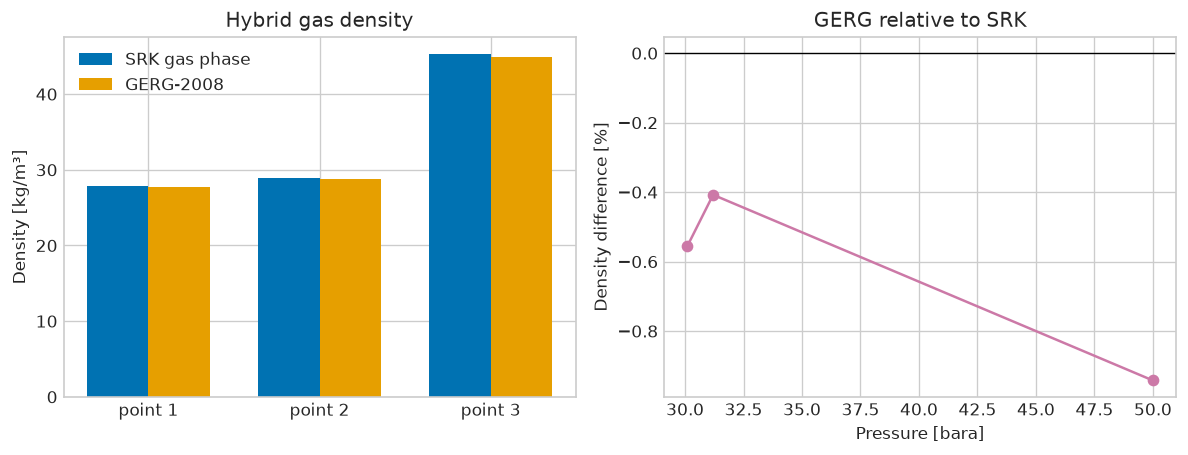

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
positions = np.arange(len(hybrid_results))
width = 0.36
axes[0].bar(
    positions - width / 2,
    hybrid_results["SRK_density"],
    width,
    label="SRK gas phase",
    color="#0072B2",
)
axes[0].bar(
    positions + width / 2,
    hybrid_results["GERG_density"],
    width,
    label="GERG-2008",
    color="#E69F00",
)
axes[0].set(
    title="Hybrid gas density",
    ylabel="Density [kg/m³]",
    xticks=positions,
    xticklabels=hybrid_results["case"],
)
axes[0].legend()
axes[1].plot(
    hybrid_results["pressure_bara"],
    hybrid_results["density_difference_pct"],
    "o-",
    color="#CC79A7",
)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set(
    title="GERG relative to SRK",
    xlabel="Pressure [bara]",
    ylabel="Density difference [%]",
)
fig.tight_layout()
plt.show()


The model difference is reported rather than hidden:

$$
\Delta \rho_{\mathrm{rel}}
= 100\left(\frac{\rho_{\mathrm{GERG}}}
{\rho_{\mathrm{SRK}}} - 1\right)
$$

This is a model comparison, not evidence that either result matches a specific
laboratory sample.


## Example 5 — direct GERG-2008 natural-gas properties

An 87/10/2/1 mol% methane/ethane/propane/n-heptane gas is evaluated with
GERG-2008 as a single gas phase over a pressure sweep at 298 K.


In [16]:
natural_gas_components = [
    "methane",
    "ethane",
    "propane",
    "n-heptane",
]
natural_gas_fractions = [0.87, 0.10, 0.02, 0.01]
validate_composition(
    natural_gas_components,
    natural_gas_fractions,
    "GERG natural gas",
)
gerg_rows = []

for pressure_bara in np.linspace(10.0, 100.0, 10):
    gas = fluid("gerg-2008", 298.0, float(pressure_bara))
    for name, fraction in zip(
        natural_gas_components,
        natural_gas_fractions,
    ):
        addComponent(gas, name, fraction)
    gas.setNumberOfPhases(1)
    gas.init(3)
    gas.initPhysicalProperties()
    phase = gas.getPhase(0)
    gerg_rows.append(
        {
            "temperature_K": 298.0,
            "pressure_bara": pressure_bara,
            "density_kg_per_m3": float(phase.getDensity("kg/m3")),
            "Z": float(phase.getZ()),
            "Cp_J_per_molK": float(phase.getCp("J/molK")),
            "viscosity_Pa_s": float(phase.getViscosity("kg/msec")),
        }
    )

gerg_results = pd.DataFrame(gerg_rows)
print(gerg_results.to_string(index=False))


 temperature_K  pressure_bara  density_kg_per_m3        Z  Cp_J_per_molK  viscosity_Pa_s
         298.0           10.0           7.803023 0.974902      40.771651        0.000011
         298.0           20.0          16.020333 0.949691      42.292019        0.000011
         298.0           30.0          24.685276 0.924501      44.007546        0.000012
         298.0           40.0          33.828815 0.899492      45.933298        0.000012
         298.0           50.0          43.476338 0.874865      48.078341        0.000012
         298.0           60.0          53.642724 0.850873      50.439608        0.000013
         298.0           70.0          64.325517 0.827826      52.993869        0.000013
         298.0           80.0          75.496588 0.806096      55.689315        0.000014
         298.0           90.0          87.093837 0.786102      58.440156        0.000014
         298.0          100.0          99.015749 0.768280      61.129042        0.000015


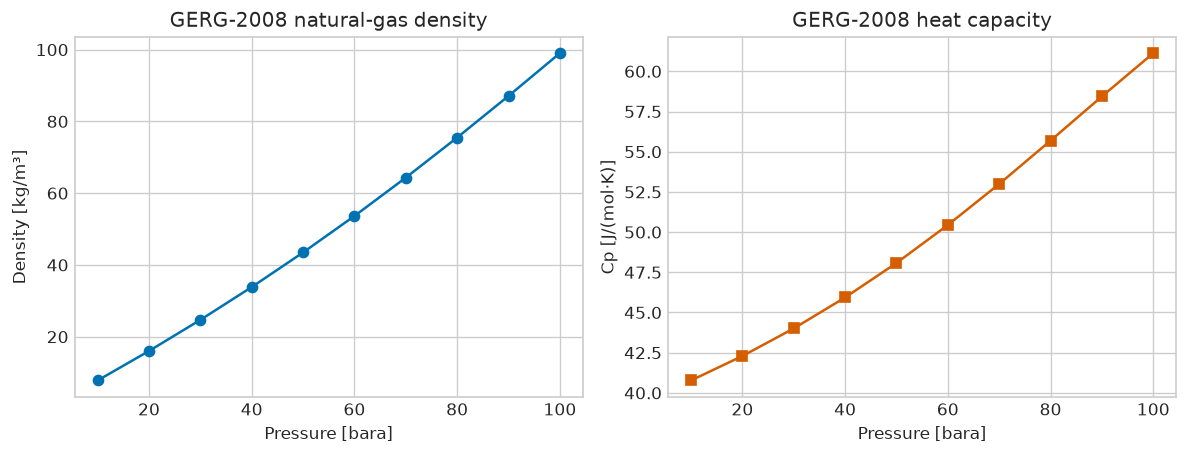

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
axes[0].plot(
    gerg_results["pressure_bara"],
    gerg_results["density_kg_per_m3"],
    "o-",
    color="#0072B2",
)
axes[0].set(
    title="GERG-2008 natural-gas density",
    xlabel="Pressure [bara]",
    ylabel="Density [kg/m³]",
)
axes[1].plot(
    gerg_results["pressure_bara"],
    gerg_results["Cp_J_per_molK"],
    "s-",
    color="#D55E00",
)
axes[1].set(
    title="GERG-2008 heat capacity",
    xlabel="Pressure [bara]",
    ylabel="Cp [J/(mol·K)]",
)
fig.tight_layout()
plt.show()


Density increases monotonically with pressure. GERG should be preferred for
high-accuracy natural-gas properties when the composition and state are inside
its documented range; phase-equilibrium screening remains necessary before
forcing a single gas phase.


## Example 6 — CPA temperature sweep

The CPA study runs 100 TP flashes from 300 to 399 K at 50 bara. CPA represents
water association while the characterized heavy fractions remain explicit.


In [18]:
cpa_rows = []
cpa_systems = []

for temperature_k in np.arange(300.0, 400.0, 1.0):
    cpa = build_fluid(
        "cpa",
        float(temperature_k),
        50.0,
        condensate_components,
        condensate_fractions,
        pseudo=heavy_fraction,
        mixing_rule=10,
    )
    cpa, _ = run_tp_case(cpa, f"{temperature_k:.0f} K")
    fractions = phase_fraction_map(cpa)
    surface_tensions = []
    for first in range(cpa.getNumberOfPhases()):
        for second in range(first + 1, cpa.getNumberOfPhases()):
            surface_tensions.append(
                float(
                    cpa.getInterphaseProperties().getSurfaceTension(
                        first,
                        second,
                    )
                )
            )
    cpa_systems.append(cpa)
    cpa_rows.append(
        {
            "temperature_K": temperature_k,
            "gas": fractions.get("gas", 0.0),
            "oil": fractions.get("oil", 0.0),
            "aqueous": fractions.get("aqueous", 0.0),
            "max_interfacial_tension_N_per_m": max(surface_tensions),
        }
    )

cpa_sweep = pd.DataFrame(cpa_rows)
print(cpa_sweep.iloc[[0, 20, 40, 60, 80, 99]].to_string(index=False))


 temperature_K      gas      oil  aqueous  max_interfacial_tension_N_per_m
         300.0 0.056169 0.693917 0.249914                         0.052881
         320.0 0.084963 0.665748 0.249289                         0.052224
         340.0 0.112146 0.639892 0.247961                         0.051169
         360.0 0.139587 0.615211 0.245203                         0.049743
         380.0 0.169669 0.590612 0.239719                         0.047944
         399.0 0.204372 0.565751 0.229878                         0.045882


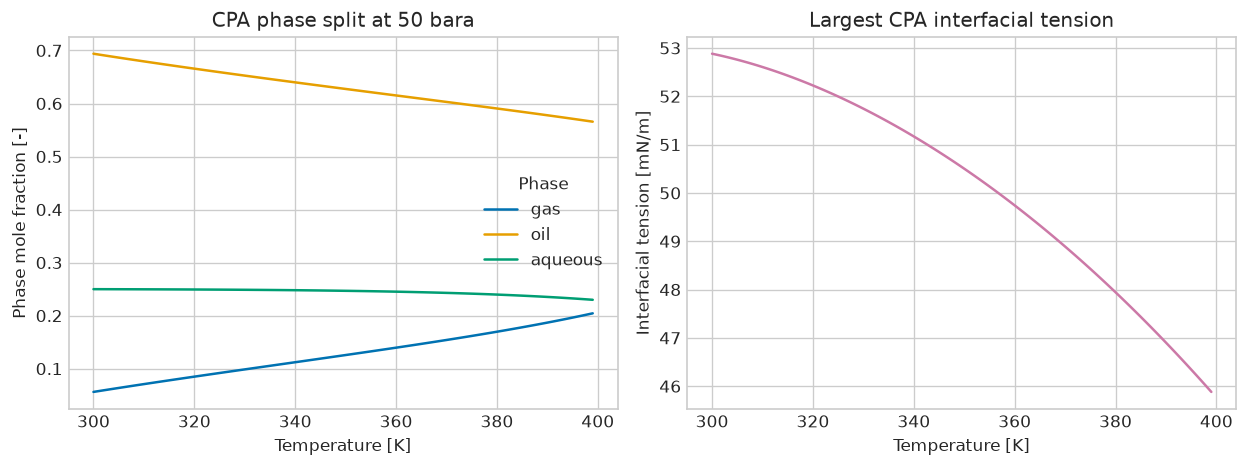

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for phase, color in zip(
    ["gas", "oil", "aqueous"],
    ["#0072B2", "#E69F00", "#009E73"],
):
    axes[0].plot(
        cpa_sweep["temperature_K"],
        cpa_sweep[phase],
        label=phase,
        color=color,
    )
axes[0].set(
    title="CPA phase split at 50 bara",
    xlabel="Temperature [K]",
    ylabel="Phase mole fraction [-]",
)
axes[0].legend(title="Phase")
axes[1].plot(
    cpa_sweep["temperature_K"],
    1000.0 * cpa_sweep["max_interfacial_tension_N_per_m"],
    color="#CC79A7",
)
axes[1].set(
    title="Largest CPA interfacial tension",
    xlabel="Temperature [K]",
    ylabel="Interfacial tension [mN/m]",
)
fig.tight_layout()
plt.show()


The interfacial-tension result is positive and finite throughout the sweep. The
screening relationship is summarized as

$$
\sigma_{\alpha\beta}(T, P, \mathbf{z}) \geq 0
$$

Interfacial-tension predictions are model-dependent and should be benchmarked
against measurements for separator or flow-assurance design.


## Engineering summary

The summary below presents representative results from each workflow in one
engineering table.


### Interpretation

The numerical tables are the primary evidence. Each figure is paired with
explicit units and a nearby statement of what can—and cannot—be inferred from
the trend.


In [20]:
summary = pd.DataFrame(
    [
        {
            "workflow": "pure methane / SRK",
            "representative_result": (
                f"{methane_results.iloc[0]['density_kg_per_m3']:.2f} kg/m³"
            ),
        },
        {
            "workflow": "defined three-phase fluid",
            "representative_result": ", ".join(
                phase_names(defined_systems[0])
            ),
        },
        {
            "workflow": "characterized condensate / SRK",
            "representative_result": (
                f"gas beta={srk_sweep.iloc[0]['gas']:.3f} at 300 K"
            ),
        },
        {
            "workflow": "SRK + GERG hybrid",
            "representative_result": (
                f"coverage={hybrid_results['GERG_coverage'].min():.4f}"
            ),
        },
        {
            "workflow": "natural gas / GERG-2008",
            "representative_result": (
                f"{gerg_results.iloc[2]['density_kg_per_m3']:.2f} kg/m³ "
                "near 30 bara"
            ),
        },
        {
            "workflow": "characterized condensate / CPA",
            "representative_result": (
                f"{len(cpa_sweep)} converged TP flashes"
            ),
        },
    ]
)
print(summary.to_string(index=False))


                      workflow    representative_result
            pure methane / SRK              20.51 kg/m³
     defined three-phase fluid        gas, oil, aqueous
characterized condensate / SRK  gas beta=0.051 at 300 K
             SRK + GERG hybrid          coverage=0.9974
       natural gas / GERG-2008 24.69 kg/m³ near 30 bara
characterized condensate / CPA 100 converged TP flashes


## Validation

The checks cover composition closure, phase closure, finite properties,
qualitative trends, hybrid-model coverage, and deterministic repeatability.


### Reproducibility gate

All checks run from the same top-to-bottom notebook state. A failed assertion
stops execution so an incomplete result cannot be mistaken for a validated
publication.


In [21]:
checks = []


def check(condition, message):
    if not bool(condition):
        raise AssertionError(message)
    checks.append(message)


check(
    math.isclose(sum(defined_fractions), 1.0, abs_tol=1.0e-12),
    "defined-fluid composition closes",
)
check(
    math.isclose(
        sum(condensate_fractions) + sum(heavy_fraction["fractions"]),
        1.0,
        abs_tol=1.0e-12,
    ),
    "characterized-condensate composition closes",
)
check(
    all(system.getNumberOfPhases() == 1 for system in methane_systems),
    "pure methane remains single phase",
)
check(
    (methane_results["density_kg_per_m3"] > 0.0).all(),
    "methane densities are positive",
)
check(
    methane_results["Z"].between(0.7, 1.1).all(),
    "methane compressibility factors are plausible",
)
check(
    set(phase_names(defined_systems[0])) == {"gas", "oil", "aqueous"},
    "defined fluid resolves gas, oil, and aqueous phases",
)
check(
    all(
        math.isclose(
            sum(phase_fraction_map(system).values()),
            1.0,
            abs_tol=1.0e-9,
        )
        for system in defined_systems
    ),
    "defined-fluid phase fractions close",
)
check(
    np.allclose(
        srk_sweep[["gas", "oil", "aqueous"]].sum(axis=1),
        1.0,
        atol=1.0e-9,
    ),
    "SRK sweep phase fractions close",
)
check(
    (hybrid_results["GERG_coverage"] > 0.98).all(),
    "GERG mapping covers more than 98% of the SRK gas phase",
)
check(
    np.isfinite(
        hybrid_results[["SRK_density", "GERG_density"]].to_numpy()
    ).all(),
    "hybrid densities are finite",
)
check(
    hybrid_results["density_difference_pct"].abs().max() < 10.0,
    "SRK and GERG gas densities agree within 10%",
)
check(
    (np.diff(gerg_results["density_kg_per_m3"]) > 0.0).all(),
    "GERG gas density increases with pressure",
)
check(
    np.allclose(
        cpa_sweep[["gas", "oil", "aqueous"]].sum(axis=1),
        1.0,
        atol=1.0e-9,
    )
    and (
        cpa_sweep["max_interfacial_tension_N_per_m"] >= 0.0
    ).all()
    and np.isfinite(cpa_sweep.to_numpy()).all(),
    "CPA sweep closes and returns finite nonnegative interfacial tension",
)

print(f"{len(checks)} engineering checks passed")
for index, message in enumerate(checks, start=1):
    print(f"{index:02d}. PASS — {message}")


13 engineering checks passed
01. PASS — defined-fluid composition closes
02. PASS — characterized-condensate composition closes
03. PASS — pure methane remains single phase
04. PASS — methane densities are positive
05. PASS — methane compressibility factors are plausible
06. PASS — defined fluid resolves gas, oil, and aqueous phases
07. PASS — defined-fluid phase fractions close
08. PASS — SRK sweep phase fractions close
09. PASS — GERG mapping covers more than 98% of the SRK gas phase
10. PASS — hybrid densities are finite
11. PASS — SRK and GERG gas densities agree within 10%
12. PASS — GERG gas density increases with pressure
13. PASS — CPA sweep closes and returns finite nonnegative interfacial tension


## Limitations

- These are educational screening cases, not certified fluid models.
- Pseudo-component characterization should be fitted to laboratory PVT data.
- GERG-2008 is forced to one gas phase only after a separate equilibrium check.
- CPA mixing rules and binary parameters should be reviewed for the actual
  water/hydrocarbon system.
- Transport and interfacial properties require experimental validation for
  detailed equipment design.


## References and next steps

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim Python examples](https://github.com/equinor/neqsimpython)
- [NeqSim source repository](https://github.com/equinor/neqsim)

Suggested exercises: replace the teaching composition with a measured fluid,
compare SRK and PR, fit pseudo-components to a CCE or CVD dataset, and add
uncertainty bands around the model comparison.


In [22]:
from datetime import datetime, timezone

validation_record = {
    "neqsim_version": version("neqsim"),
    "python_version": sys.version.split()[0],
    "executed_at_utc": datetime.now(timezone.utc).isoformat(),
    "code_cells": 22,
    "engineering_checks": len(checks),
    "figures": 6,
    "use_cases": 6,
}
print(validation_record)


{'neqsim_version': '3.16.0', 'python_version': '3.12.13', 'executed_at_utc': '2026-07-25T10:56:27.696584+00:00', 'code_cells': 22, 'engineering_checks': 13, 'figures': 6, 'use_cases': 6}
